In [1]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Access the features and target variable
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target variable (species: 0 for setosa, 1 for versicolor, 2 for virginica)

# Print the feature names and target names
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

# Print the first few samples in the dataset
print("First 5 samples:")
for i in range(5):
    print(f"Sample {i+1}: {X[i]} (Class: {y[i]}, Species: {iris.target_names[y[i]]})")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
First 5 samples:
Sample 1: [5.1 3.5 1.4 0.2] (Class: 0, Species: setosa)
Sample 2: [4.9 3.  1.4 0.2] (Class: 0, Species: setosa)
Sample 3: [4.7 3.2 1.3 0.2] (Class: 0, Species: setosa)
Sample 4: [4.6 3.1 1.5 0.2] (Class: 0, Species: setosa)
Sample 5: [5.  3.6 1.4 0.2] (Class: 0, Species: setosa)


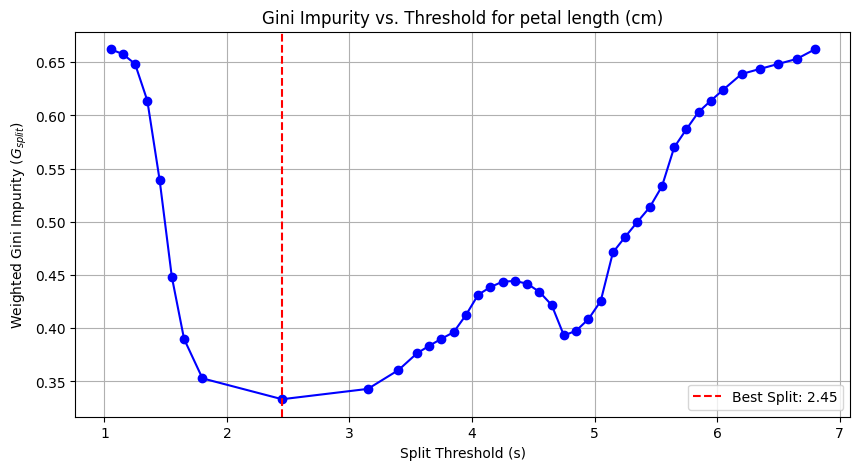

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Gini Impurity Calculation
def gini_impurity(y):
    """Calculates the Gini impurity for a set of class labels."""
    m = len(y)
    if m == 0:
        return 0.0
    
    # Count occurrences of each class
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / m
    
    # G = 1 - sum(p_i^2)
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini

def evaluate_split(X_column, y, threshold):
    """Evaluates a split based on a specific threshold."""
    # Create masks for LHS and RHS regions
    lhs_mask = X_column < threshold
    rhs_mask = ~lhs_mask
    
    y_lhs = y[lhs_mask]
    y_rhs = y[rhs_mask]
    
    n_lhs = len(y_lhs)
    n_rhs = len(y_rhs)
    n_total = n_lhs + n_rhs
    
    if n_lhs == 0 or n_rhs == 0:
        return float('inf') # Invalid split
        
    # Compute weighted Gini impurity
    g_lhs = gini_impurity(y_lhs)
    g_rhs = gini_impurity(y_rhs)
    
    g_split = (n_lhs / n_total) * g_lhs + (n_rhs / n_total) * g_rhs
    return g_split

# --- Visualizing Step 1: Finding the Best Split ---
iris = load_iris()
X = iris.data[:, 2:4] # Use Petal Length and Petal Width for easy 2D visualization
y = iris.target

# Let's visualize finding the best split for Feature 0 (Petal Length)
feature_idx = 0
X_col = X[:, feature_idx]

# Find all possible split locations as per the slide: midpoints between unique values
unique_vals = np.sort(np.unique(X_col))
split_locations = (unique_vals[:-1] + unique_vals[1:]) / 2

# Evaluate all splits
gini_scores = [evaluate_split(X_col, y, s) for s in split_locations]
best_split_idx = np.argmin(gini_scores)
best_threshold = split_locations[best_split_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(split_locations, gini_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Split: {best_threshold:.2f}')
plt.title(f"Gini Impurity vs. Threshold for {iris.feature_names[2]}")
plt.xlabel("Split Threshold (s)")
plt.ylabel("Weighted Gini Impurity ($G_{split}$)")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
from collections import Counter

class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index # Index of feature used for splitting
        self.threshold = threshold         # Value used for splitting
        self.left = left                   # Left child Node (LHS)
        self.right = right                 # Right child Node (RHS)
        self.value = value                 # Class prediction (only for leaf nodes)

class CustomCART:
    def __init__(self, min_samples_split=2, max_depth=10):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # 1. Check Stopping Criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # 2. Find the best split (Algorithm from slide)
        best_feat, best_thresh = self._best_split(X, y, n_features)
        
        # If no valid split is found (e.g., all features are identical)
        if best_feat is None:
             leaf_value = self._most_common_label(y)
             return Node(value=leaf_value)

        # 3. Split the tree
        lhs_mask = X[:, best_feat] < best_thresh
        rhs_mask = ~lhs_mask
        
        # 4. Continue recursively
        left_child = self._grow_tree(X[lhs_mask, :], y[lhs_mask], depth + 1)
        right_child = self._grow_tree(X[rhs_mask, :], y[rhs_mask], depth + 1)
        
        return Node(feature_index=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_features):
        best_gini = float('inf')
        best_feat, best_thresh = None, None

        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            
            # Find all possible split locations: S_{x_j}
            unique_vals = np.sort(np.unique(X_column))
            split_locations = (unique_vals[:-1] + unique_vals[1:]) / 2

            for threshold in split_locations:
                gini = evaluate_split(X_column, y, threshold)

                if gini < best_gini:
                    best_gini = gini
                    best_feat = feat_idx
                    best_thresh = threshold

        return best_feat, best_thresh

    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature_index] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

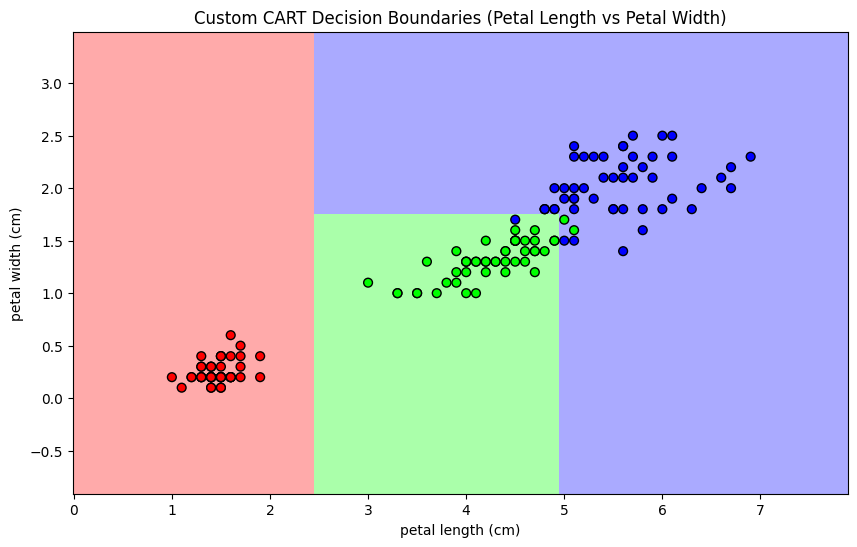

In [4]:
from matplotlib.colors import ListedColormap

# Train our custom model
tree = CustomCART(max_depth=3) # Limit depth for visualization clarity
tree.fit(X, y)

# --- Visualizing Step 4: Decision Boundaries ---
def plot_decision_boundary(X, y, model):
    h = .02  # Step size in the mesh
    
    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict across the entire grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=40)
    plt.title("Custom CART Decision Boundaries (Petal Length vs Petal Width)")
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])
    plt.show()

plot_decision_boundary(X, y, tree)